In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Hàm tách số từ chữ (vd: '500 sqft' -> 500)
def extract_number(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r"[\d\.]+", str(val).replace(',', ''))
    if nums:
        try: return float(nums[0])
        except: pass
    return np.nan

# Hàm quy đổi 'Lac' và 'Cr' ra số thực tế
def parse_amount(val):
    if pd.isna(val): return np.nan
    val_str = str(val).lower().replace(',', '')
    num = extract_number(val_str)
    if pd.isna(num): return np.nan
    if 'lac' in val_str: return num * 100000        
    elif 'cr' in val_str: return num * 10000000     
    else: return num

In [2]:
# 1. Đọc dữ liệu
df = pd.read_csv('house_prices.csv')

# 2. Làm sạch
df['Price_Rupees'] = df['Amount(in rupees)'].apply(parse_amount)
df['Area_Sqft'] = df['Carpet Area'].apply(extract_number)
df['Baths'] = df['Bathroom'].apply(extract_number)

# 3. Lọc bỏ dữ liệu rỗng và nhiễu
df_clean = df[['Price_Rupees', 'Area_Sqft', 'Baths']].dropna()
df_clean = df_clean[(df_clean['Area_Sqft'] < 10000) & (df_clean['Price_Rupees'] < 500000000)]

print(f"✅ Đã dọn dẹp xong! Còn lại {df_clean.shape[0]} căn nhà hợp lệ.")
print("👉 BẢNG DỮ LIỆU ĐÃ ĐƯỢC LÀM SẠCH (5 dòng đầu):")

# Dùng display() để hiện bảng đẹp trên Colab
display(df_clean.head())

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_21940\1342671276.py:2: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('house_prices.csv')


✅ Đã dọn dẹp xong! Còn lại 92015 căn nhà hợp lệ.
👉 BẢNG DỮ LIỆU ĐÃ ĐƯỢC LÀM SẠCH (5 dòng đầu):


,Price_Rupees,Area_Sqft,Baths
0,4200000.0,500.0,1.0
1,9800000.0,473.0,2.0
2,14000000.0,779.0,2.0
3,2500000.0,530.0,1.0
4,16000000.0,635.0,2.0


✅ Đã học xong! Điểm số R-squared: 0.56
👉 BẢNG KIỂM TRA CHÉO (10 căn nhà ngẫu nhiên):


,Diện tích (sqft),Phòng tắm,Giá Thực tế (INR),Giá AI Đoán (INR),Mức độ lệch (INR)
719,1350.0,3.0,42500000.0,17830539.0,24669461.0
4092,140.0,3.0,15500000.0,6828696.0,8671304.0
149586,890.0,2.0,1600000.0,7905794.0,6305794.0
159904,110.0,3.0,11000000.0,6555923.0,4444077.0
104590,745.0,2.0,4200000.0,6587391.0,2387391.0
70041,3600.0,4.0,39800000.0,44030738.0,4230738.0
153060,1600.0,3.0,8000000.0,20103647.0,12103647.0
148973,540.0,1.0,2200000.0,-1018783.0,3218783.0
109210,745.0,2.0,4200000.0,6587391.0,2387391.0
142662,1570.0,3.0,17500000.0,19830874.0,2330874.0


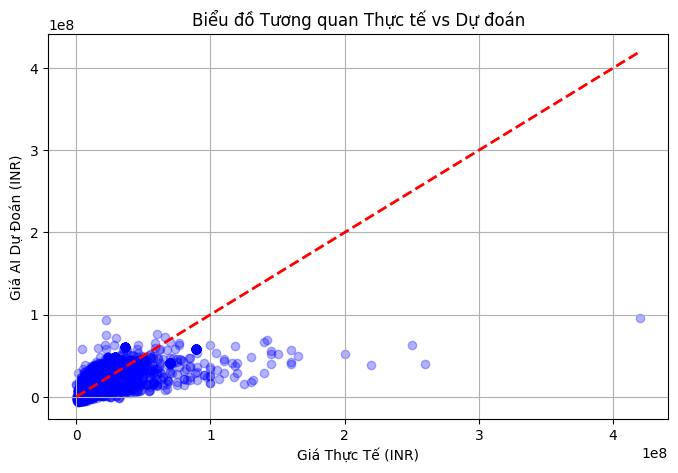

In [3]:
# 1. Chia dữ liệu
X = df_clean[['Area_Sqft', 'Baths']]
y = df_clean['Price_Rupees']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Huấn luyện mô hình Hồi quy tuyến tính
model = LinearRegression()
model.fit(X_train, y_train)

# 3. AI làm bài thi dự đoán
y_pred = model.predict(X_test)

# 4. Tạo BẢNG SO SÁNH Thực tế vs Dự đoán
df_compare = pd.DataFrame({
    'Diện tích (sqft)': X_test['Area_Sqft'],
    'Phòng tắm': X_test['Baths'],
    'Giá Thực tế (INR)': y_test,
    'Giá AI Đoán (INR)': np.round(y_pred, 0)
})
df_compare['Mức độ lệch (INR)'] = abs(df_compare['Giá Thực tế (INR)'] - df_compare['Giá AI Đoán (INR)'])

print(f"✅ Đã học xong! Điểm số R-squared: {r2_score(y_test, y_pred):.2f}")
print("👉 BẢNG KIỂM TRA CHÉO (10 căn nhà ngẫu nhiên):")
display(df_compare.head(10))

# 5. Vẽ biểu đồ
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Giá Thực Tế (INR)')
plt.ylabel('Giá AI Dự Đoán (INR)')
plt.title('Biểu đồ Tương quan Thực tế vs Dự đoán')
plt.grid(True)
plt.show()

In [4]:
import IPython.display as display_module

# 1. BẢNG THỐNG KÊ MÔ TẢ TỔNG QUAN
print("📊 BẢNG 1: THỐNG KÊ MÔ TẢ TỔNG QUAN (Giá trung bình, Lớn nhất, Nhỏ nhất...)")
bang_thong_ke = df_clean.describe().round(2)
bang_thong_ke.columns = ['Giá nhà (INR)', 'Diện tích (sqft)', 'Phòng tắm']
display_module.display(bang_thong_ke)

# 2. MA TRẬN TƯƠNG QUAN
print("\n🔗 BẢNG 2: MỨC ĐỘ TƯƠNG QUAN GIỮA CÁC YẾU TỐ (Càng gần 1 càng tỷ lệ thuận)")
bang_tuong_quan = df_clean.corr().round(3)
display_module.display(bang_tuong_quan)

# 3. PHÂN TÍCH NHÓM PHÒNG TẮM
print("\n🛁 BẢNG 3: PHÂN TÍCH THỊ TRƯỜNG THEO SỐ LƯỢNG PHÒNG TẮM")
bang_nhom_pt = df_clean.groupby('Baths')['Price_Rupees'].agg(
    Số_Lượng_Nhà='count', 
    Giá_Trung_Bình='mean', 
    Giá_Cao_Nhất='max'
).round(0)
pd.options.display.float_format = '{:,.0f}'.format
display_module.display(bang_nhom_pt)

# 4. MỔ XẺ SAI SỐ TRÊN TẬP TEST
print("\n⚠️ BẢNG 4: TOP 5 CĂN NHÀ AI DỰ ĐOÁN SAI LỆCH NHIỀU NHẤT (Cần xem xét lại dữ liệu)")
df_sai_so = pd.DataFrame({
    'Diện tích': X_test['Area_Sqft'],
    'Phòng tắm': X_test['Baths'],
    'Giá Thực tế': y_test,
    'Giá Dự đoán': np.round(y_pred, 0)
})
df_sai_so['Lệch (INR)'] = abs(df_sai_so['Giá Thực tế'] - df_sai_so['Giá Dự đoán'])
df_sai_so['Lệch (%)'] = (df_sai_so['Lệch (INR)'] / df_sai_so['Giá Thực tế']) * 100
top_5_sai_so = df_sai_so.sort_values(by='Lệch (%)', ascending=False).head(5)
display_module.display(top_5_sai_so)

📊 BẢNG 1: THỐNG KÊ MÔ TẢ TỔNG QUAN (Giá trung bình, Lớn nhất, Nhỏ nhất...)


,Giá nhà (INR),Diện tích (sqft),Phòng tắm
count,9.201500e+04,92015.00,92015.00
mean,1.387982e+07,1202.78,2.54
std,1.496941e+07,753.25,0.91
min,1.100000e+05,2.00,1.00
25%,5.100000e+06,759.00,2.00
50%,8.500000e+06,1050.00,2.00
75%,1.750000e+07,1500.00,3.00
max,4.800000e+08,9029.00,10.00



🔗 BẢNG 2: MỨC ĐỘ TƯƠNG QUAN GIỮA CÁC YẾU TỐ (Càng gần 1 càng tỷ lệ thuận)


,Price_Rupees,Area_Sqft,Baths
Price_Rupees,1.000,0.714,0.687
Area_Sqft,0.714,1.000,0.740
Baths,0.687,0.740,1.000



🛁 BẢNG 3: PHÂN TÍCH THỊ TRƯỜNG THEO SỐ LƯỢNG PHÒNG TẮM


,Số_Lượng_Nhà,Giá_Trung_Bình,Giá_Cao_Nhất
Baths,,,
1,7286,"3,058,492","270,000,000"
2,43364,"7,618,157","80,000,000"
3,28520,"16,176,176","270,000,000"
4,10038,"29,273,650","340,000,000"
5,2680,"59,499,381","480,000,000"
6,97,"67,079,381","235,000,000"
7,13,"133,192,308","420,000,000"
8,3,"108,333,333","140,000,000"
9,3,"205,333,333","300,000,000"



⚠️ BẢNG 4: TOP 5 CĂN NHÀ AI DỰ ĐOÁN SAI LỆCH NHIỀU NHẤT (Cần xem xét lại dữ liệu)


,Diện tích,Phòng tắm,Giá Thực tế,Giá Dự đoán,Lệch (INR),Lệch (%)
167186,"1,025",3,"140,000","14,875,498","14,735,498","10,525"
147683,448,4,"260,000","15,371,391","15,111,391","5,812"
114101,"1,980",4,"1,450,000","29,300,997","27,850,997","1,921"
147391,"6,363",2,"4,000,000","57,668,676","53,668,676","1,342"
156353,300,1,"300,000","-3,200,967","3,500,967","1,167"


In [5]:
# Tỷ giá ước tính: 1 Rupee Ấn Độ (INR) ~ 305 VNĐ
TY_GIA = 305

# 1. BẠN NHẬP THÔNG TIN VÀO ĐÂY:
dien_tich_input = float(input("👉 Nhập Diện tích bạn muốn (sqft): "))
phong_tam_input = float(input("👉 Nhập Số phòng tắm: "))

# 2. AI ĐỊNH GIÁ
nha_moi = pd.DataFrame({'Area_Sqft': [dien_tich_input], 'Baths': [phong_tam_input]})
gia_du_doan_inr = model.predict(nha_moi)[0]
gia_du_doan_vnd = gia_du_doan_inr * TY_GIA

print(f"\n🎯 THEO AI TÍNH TOÁN, CĂN NHÀ NÀY TRỊ GIÁ KHOẢNG: {gia_du_doan_inr:,.0f} INR (~ {gia_du_doan_vnd:,.0f} VNĐ)")

# ==========================================
# PHẦN NÂNG CẤP LỌC DỮ LIỆU CHUẨN XÁC HƠN
# ==========================================
# Bước 3a: CHỈ LẤY những căn nhà có đúng số phòng tắm mà người dùng yêu cầu
df_cung_phong_tam = df_clean[df_clean['Baths'] == phong_tam_input].copy()

# (Đề phòng trường hợp hiếm: Không có căn nào có đúng số phòng tắm đó, thì đành lấy lại toàn bộ)
if df_cung_phong_tam.empty:
    print("\n⚠️ Không tìm thấy nhà có đúng số phòng tắm này, đang mở rộng tìm kiếm...")
    df_cung_phong_tam = df_clean.copy()

# Bước 3b: Trong số những căn ĐÚNG TIÊU CHÍ phòng tắm, mới tìm 5 căn sát giá AI đoán nhất
df_cung_phong_tam['Độ lệch so với AI (INR)'] = abs(df_cung_phong_tam['Price_Rupees'] - gia_du_doan_inr)
top_5 = df_cung_phong_tam.sort_values(by='Độ lệch so với AI (INR)').head(5).copy()

# ==========================================
# 4. TẠO BẢNG HIỂN THỊ KẾT QUẢ QUY ĐỔI VNĐ
top_5['Giá Thực tế (VNĐ)'] = top_5['Price_Rupees'] * TY_GIA
bang_ket_qua = top_5[['Area_Sqft', 'Baths', 'Price_Rupees', 'Giá Thực tế (VNĐ)', 'Độ lệch so với AI (INR)']].rename(columns={
    'Area_Sqft': 'Diện tích (sqft)',
    'Baths': 'Phòng tắm',
    'Price_Rupees': 'Giá Thực tế (INR)'
})

pd.options.display.float_format = '{:,.0f}'.format
print("\n🔍 ĐÂY LÀ BẢNG TOP 5 CĂN NHÀ ĐANG BÁN THỎA MÃN TIÊU CHÍ CỦA BẠN:")
display_module.display(bang_ket_qua)


🎯 THEO AI TÍNH TOÁN, CĂN NHÀ NÀY TRỊ GIÁ KHOẢNG: 10,927,958,952 INR (~ 3,333,027,480,496 VNĐ)

🔍 ĐÂY LÀ BẢNG TOP 5 CĂN NHÀ ĐANG BÁN THỎA MÃN TIÊU CHÍ CỦA BẠN:


,Diện tích (sqft),Phòng tắm,Giá Thực tế (INR),Giá Thực tế (VNĐ),Độ lệch so với AI (INR)
50848,"5,500",5,"480,000,000","146,400,000,000","10,447,958,952"
52866,"5,400",5,"420,000,000","128,100,000,000","10,507,958,952"
49975,"4,800",5,"270,000,000","82,350,000,000","10,657,958,952"
51531,"5,000",5,"250,000,000","76,250,000,000","10,677,958,952"
117735,"6,000",5,"240,000,000","73,200,000,000","10,687,958,952"
